In [29]:
import csv
from pathlib import Path
import datetime as dt

raw_csv_path = Path("../results/sensor_low_peaks-2.csv")
clean_csv_path = raw_csv_path.with_name("sensor_low_peaks-2_cleaned.csv")

# Apply a fixed delay before any ordering or grouping.
TIMESTAMP_DELAY_MS_BY_SOURCE = {
    "sensor_data_20260607_215231.csv": -300,
}


def ms_to_iso8601(timestamp_ms: int) -> str:
    return dt.datetime.fromtimestamp(timestamp_ms / 1000.0, tz=dt.timezone.utc).isoformat()


def load_peak_rows(path: Path) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []
    with path.open("r", newline="") as file:
        reader = csv.DictReader(file)
        for row in reader:
            sources = [part for part in row["sources"].split(";") if part]
            timestamp_ms = int(row["timestamp_ms"])
            delay_ms = max((TIMESTAMP_DELAY_MS_BY_SOURCE.get(source, 0) for source in sources), default=0)
            rows.append(
                {
                    "peak_number": int(row["peak_number"]),
                    "timestamp_ms": timestamp_ms + delay_ms,
                    "sources": sources,
                    "source_key": row["sources"],
                }
            )
    return sorted(rows, key=lambda row: row["timestamp_ms"])


def merge_repeated_source_runs(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    if not rows:
        return []

    cleaned: list[dict[str, object]] = []
    run: list[dict[str, object]] = [rows[0]]
    current_key = rows[0]["source_key"]

    def flush(current_run: list[dict[str, object]]) -> None:
        first_row = current_run[0]
        last_row = current_run[-1]
        midpoint_ms = int(round((int(first_row["timestamp_ms"]) + int(last_row["timestamp_ms"])) / 2))
        merged_sources: list[str] = []
        for row in current_run:
            for source in row["sources"]:
                if source not in merged_sources:
                    merged_sources.append(source)

        cleaned.append(
            {
                "peak_number": len(cleaned) + 1,
                "timestamp_ms": midpoint_ms,
                "timestamp_utc": ms_to_iso8601(midpoint_ms),
                "sources": ";".join(merged_sources),
                "merged_count": len(current_run),
            }
        )

    for row in rows[1:]:
        if row["source_key"] == current_key:
            run.append(row)
        else:
            flush(run)
            run = [row]
            current_key = row["source_key"]

    flush(run)
    return cleaned


raw_rows = load_peak_rows(raw_csv_path)
cleaned_rows = merge_repeated_source_runs(raw_rows)

clean_csv_path.parent.mkdir(parents=True, exist_ok=True)
with clean_csv_path.open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=["peak_number", "timestamp_ms", "timestamp_utc", "sources", "merged_count"])
    writer.writeheader()
    writer.writerows(cleaned_rows)

print(f"Saved cleaned CSV to: {clean_csv_path}")
print(f"Original peaks: {len(raw_rows)}, cleaned peaks: {len(cleaned_rows)}")

Saved cleaned CSV to: ../results/sensor_low_peaks-2_cleaned.csv
Original peaks: 336, cleaned peaks: 319


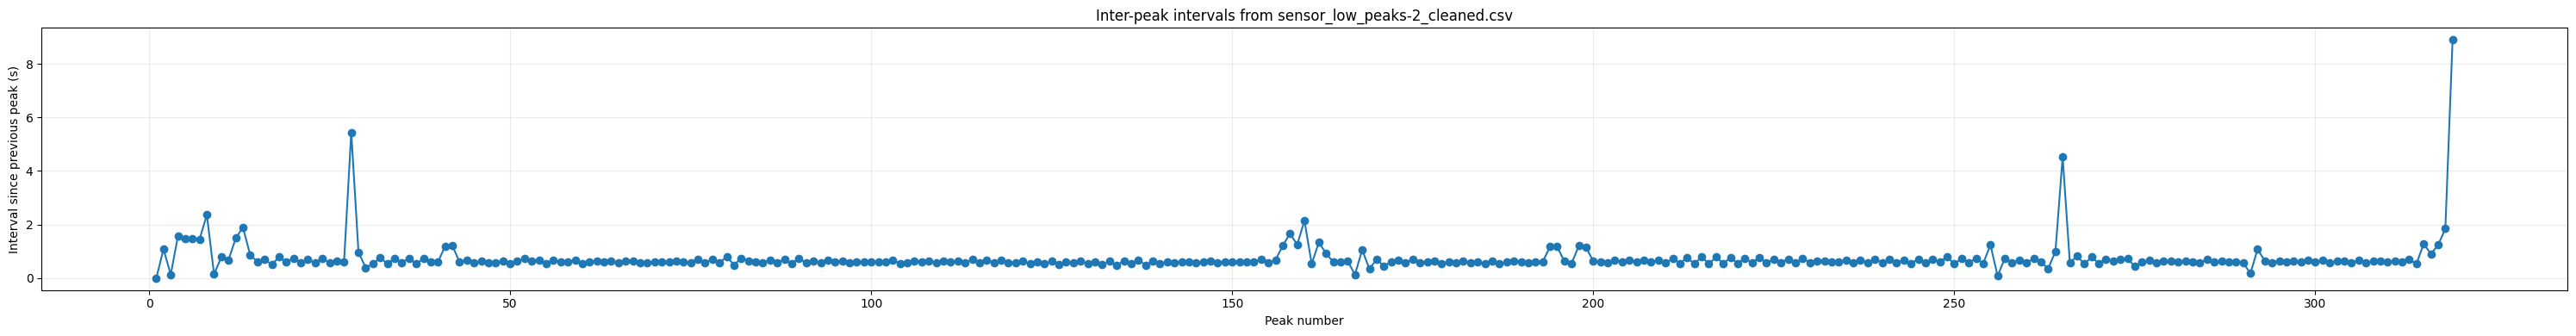

Saved plot to: ../results/inter_peak_intervals_cleaned.png
Peaks: 319, median interval: 0.619s, mean interval: 0.732s


In [30]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import statistics as _st

csv_path = Path("../results/sensor_low_peaks-2_cleaned.csv")

# Read timestamps and peak numbers
timestamps = []
peak_numbers = []
with csv_path.open("r", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            timestamps.append(int(row["timestamp_ms"]))
            peak_numbers.append(int(row["peak_number"]))
        except Exception:
            continue

if not timestamps:
    print(f"No data found in: {csv_path}")
else:
    # Sort by timestamp just in case
    combined = sorted(zip(timestamps, peak_numbers))
    timestamps_sorted, peaks_sorted = zip(*combined)

    # compute interval since previous peak in seconds
    deltas_s = [0.0]
    for i in range(1, len(timestamps_sorted)):
        deltas_s.append((timestamps_sorted[i] - timestamps_sorted[i-1]) / 1000.0)

    fig, ax = plt.subplots(figsize=(30, 4))
    ax.plot(list(peaks_sorted), deltas_s, marker="o", linestyle="-", color="#1f77b4")
    ax.set_xlabel("Peak number")
    ax.set_ylabel("Interval since previous peak (s)")
    ax.set_title("Inter-peak intervals from sensor_low_peaks-2_cleaned.csv")
    ax.grid(alpha=0.25)
    fig.tight_layout()

    out_path = csv_path.with_name("inter_peak_intervals_cleaned.png")
    fig.savefig(out_path, dpi=160)
    plt.show()
    plt.close(fig)

    print(f"Saved plot to: {out_path}")
    print(f"Peaks: {len(peaks_sorted)}, median interval: {_st.median(deltas_s):.3f}s, mean interval: {_st.mean(deltas_s):.3f}s")